# Univariate Statistical Outlier Detection with OSBAD

This notebook benchmarks several statistical outlier detection methods on a synthetic univariate dataset. Each method flags data points that deviate significantly from the bulk of the distribution, but they differ in how they measure the center and spread of the data:

* **Standard Deviation (SD):** Flags points that fall outside $\mu \pm 3\sigma$, where $\mu$ is the mean and $\sigma$ is the standard deviation. It assumes an approximately Gaussian distribution and is sensitive to extreme values, since outliers inflate both the mean and the standard deviation.
* **Median Absolute Deviation (MAD):** Uses the median and the median of absolute deviations from it, scaled by a factor $F_\textrm{MAD}$. Because it relies on the median rather than the mean, it is robust to extreme values and works well when the data contains strong outliers.
* **Interquartile Range (IQR):** Defines the bounds from the first and third quartiles ($Q_1$ and $Q_3$), flagging points below $Q_1 - 1.5 \times IQR$ or above $Q_3 + 1.5 \times IQR$. It is distribution free and robust, and forms the basis of the boxplot.
* **Z-Score:** Standardizes each point as $z_i = (x_i - \mu)/\sigma$ and flags those whose standardized value exceeds a chosen threshold. Like the SD method, it assumes normality and is affected by extreme values.
* **Modified Z-Score:** Replaces the mean and standard deviation with the median and MAD, giving a robust version of the Z-score that is less influenced by outliers and better suited to non Gaussian data.

Since the synthetic dataset has known injected outliers, each method is evaluated against this ground truth using a confusion matrix.


In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import duckdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.stats as bstats
import osbad.viz as bviz
from osbad.database import BenchDB
from osbad.scaler import CycleScaling
from osbad.model import ModelRunner

# Synthetic Outliers to Test OSBAD

A synthetic univariate dataset is generated to benchmark the outlier detection methods against a known ground truth:

* **Inliers:** 200 samples drawn from a normal distribution with mean $\mu = 50$ and standard deviation $\sigma = 5$.
* **Outliers:** 7 extreme values manually injected (`[10, 12, 85, 90, 95, 5, 100]`), which lie far from the inlier cluster (low outliers at 5, 10, 12 and high outliers at 85, 90, 95, 100).
* **Combined dataset:** the inliers and outliers are concatenated into 207 samples and shuffled, then stored in `df_univariate` with an `index` and a `value` column.
* A fixed random seed (`seed=42`) ensures the dataset is reproducible across runs.

Since the injected outliers are known in advance, they serve as the ground-truth labels for evaluating each detection method with a confusion matrix.


In [2]:
# Simulate a univariate dataset with several outliers
rng = np.random.default_rng(seed=42)

# Generate normally-distributed inliers
n_inliers = 200
inliers = rng.normal(loc=50, scale=5, size=n_inliers)

# Generate a few extreme outliers
outliers = np.array([10, 12, 85, 90, 95, 5, 100])

# Combine and shuffle into a single dataset
data = np.concatenate([inliers, outliers])
rng.shuffle(data)

df_univariate = pd.DataFrame({
    "index": np.arange(data.size),
    "value": data,
})

print(f"Number of samples: {df_univariate.shape[0]}")
print(f"Injected outliers: {outliers.tolist()}")
df_univariate.describe()

Number of samples: 207
Injected outliers: [10, 12, 85, 90, 95, 5, 100]


,index,value
count,207.000000,207.000000
mean,103.000000,50.079948
std,59.899917,8.893080
min,0.000000,5.000000
25%,51.500000,46.681411
50%,103.000000,49.750370
75%,154.500000,53.005504
max,206.000000,100.000000


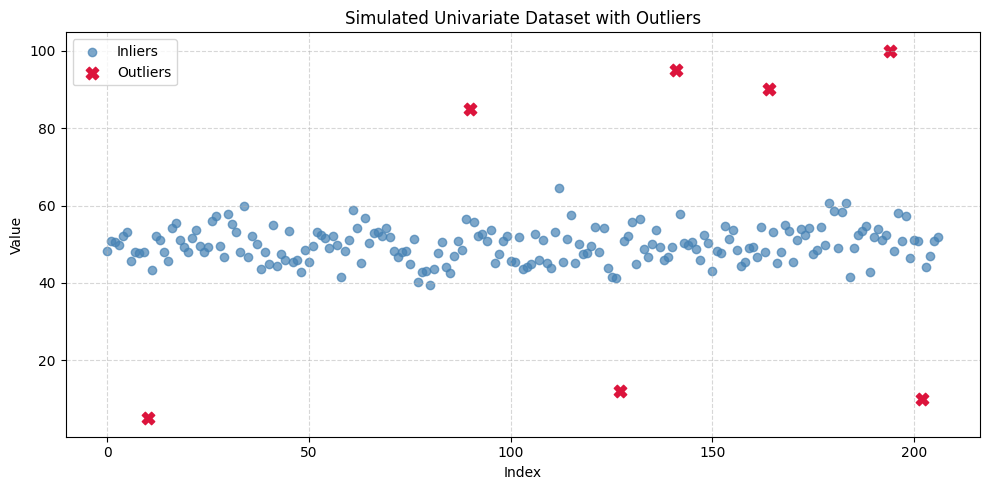

In [3]:
# Plot the univariate dataset, highlighting the injected outliers
is_outlier = df_univariate["value"].isin(outliers)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    df_univariate.loc[~is_outlier, "index"],
    df_univariate.loc[~is_outlier, "value"],
    color="steelblue",
    label="Inliers",
    alpha=0.7)
ax.scatter(
    df_univariate.loc[is_outlier, "index"],
    df_univariate.loc[is_outlier, "value"],
    color="crimson",
    label="Outliers",
    marker="X",
    s=80)

ax.grid(True, linestyle="--", alpha=0.5)

ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.set_title("Simulated Univariate Dataset with Outliers")
ax.legend()
plt.tight_layout()
plt.show()

# Outlier Detection with Standard Deviation

$$
\begin{equation}
\sigma = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(x_i - \overline{x})^2},
\end{equation}
$$

* $x_i$ represents each data point in the extracted feature, $\overline{x}$ is the sample mean and $N$ is the number of data points.
* The Bessel's correction, $N-1$, should be used in the denominator instead of $N$ when calculating the SD using the sample mean and the population mean is unknown.
* A low standard deviation indicates that the data point is close to the sample mean, whereas a high standard deviation means they are spread out over a wider range of values.
* $\mu \pm 3\sigma$ is commonly used to threshold anomalies based on SD:
   * The lower bound corresponds to $\mu - 3\sigma$
   * The upper bound corresponds to $\mu + 3\sigma$.

In [4]:
# Access the dict of parameters for using 
# the standard deviation method 
sd_param_dict = bstats.outlier_method["sd"].params
print(sd_param_dict)

# Predict the anomalous cycle using standard dev method 
# and the corresponding stats parameters
(SD_outlier_index,
 SD_min_limit,
 SD_max_limit) = bstats.outlier_method["sd"].compute(
    df_univariate["value"], 
    **sd_param_dict)

print("*"*70)
print(df_univariate[df_univariate["index"].isin(SD_outlier_index)])
print("*"*70)

{'std_dev_threshold': 3.0, 'ddof': 1}
SD feature mean: 50.07994819008502
SD feature std: 8.893080255727432
SD lower bound: 23.400707422902727
SD upper bound: 76.75918895726731
Std anomalous cycle index: [ 10  90 127 141 164 194 202]
**********************************************************************
     index  value
10      10    5.0
90      90   85.0
127    127   12.0
141    141   95.0
164    164   90.0
194    194  100.0
202    202   10.0
**********************************************************************


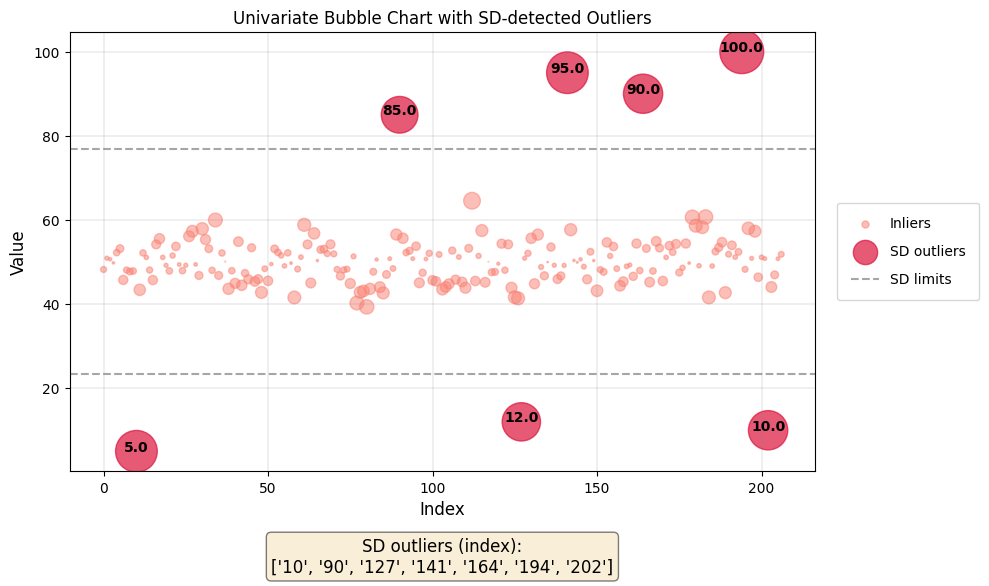

In [5]:
# Bubble chart of df_univariate with SD-detected outliers labelled
xseries = df_univariate["index"]
yseries = df_univariate["value"]

# Bubble size scales with the deviation from the mean value
bubble_size = np.abs(yseries - yseries.mean())

# Flag which points were detected as outliers by the SD method
is_sd_outlier = df_univariate["index"].isin(SD_outlier_index)

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6))

# Scatterplot for inliers
ax.scatter(
    xseries[~is_sd_outlier],
    yseries[~is_sd_outlier],
    s=bubble_size[~is_sd_outlier] * 10,
    alpha=0.5,
    marker="o",
    c="salmon",
    label="Inliers")

# Scatterplot for SD-detected outliers
ax.scatter(
    xseries[is_sd_outlier],
    yseries[is_sd_outlier],
    s=bubble_size[is_sd_outlier] * 20,
    alpha=0.7,
    marker="o",
    c="crimson",
    label="SD outliers")

# Annotate each detected outlier with its value
for idx in SD_outlier_index:
    ax.text(
        x=xseries[idx],
        y=yseries[idx],
        s=f"{yseries[idx]:.1f}",
        horizontalalignment="center",
        size="medium",
        color="black",
        weight="bold")

# Draw the SD limits used for detection
ax.axhline(SD_max_limit, color="grey", linestyle="--", alpha=0.7,
           label="SD limits")
ax.axhline(SD_min_limit, color="grey", linestyle="--", alpha=0.7)

# Textbox annotating the detected outlier indices
props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
textstr = "\n".join((
    r"SD outliers (index):",
    f"{[str(idx) for idx in SD_outlier_index]}"))
ax.text(
    0.5, -0.15,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    ha="center", va="top",
    bbox=props)

ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Univariate Bubble Chart with SD-detected Outliers")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.0,
    markerscale=0.6,
    borderpad=1.0)
plt.tight_layout()
plt.show()

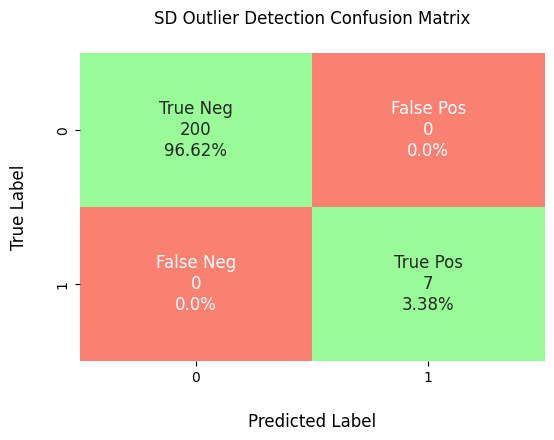

In [6]:
# Compare IQR predicted outliers with the true injected outliers
y_true = df_univariate["value"].isin(outliers)
y_pred = df_univariate["index"].isin(SD_outlier_index)

# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

fig_title = "SD Outlier Detection Confusion Matrix"

axplot.set_title(
    fig_title 
    + "\n",
    fontsize=12)

plt.show()

# Median Absolute Deviation (MAD)

$$
\begin{equation}
\textrm{MAD} = |F_\textrm{MAD}|\times \textrm{median}(|x_i - M|),
\end{equation} 
$$

* $x_i$ represents each data point in the extracted feature and
* $M$ is the median of the feature ($M = \textrm{median}(x)$).
* Then, the absolute difference from that median and median of those absolute deviations can be computed to calculate the MAD-score.
* $F_\textrm{MAD}$ is the MAD-factor:
   * If the underlying data distribution is Gaussian, then we can assume that $F_\textrm{MAD} = 1.4826$.
   * However, if one would like to relax the assumption about the normality of a feature distribution, then $F_\textrm{MAD}$ can be calculated from the reciprocal of the 75th-percentile of a standard distribution (a distribution with a mean of zero and a standard deviation of one).

In [7]:
# Access the dict of parameters for using 
# the standard deviation method 
mad_param_dict = bstats.outlier_method["mad"].params
print(mad_param_dict)

# Predict the anomalous cycle using median absolute deviation (MAD) method 
# and the corresponding stats parameters
(MAD_outlier_index,
 MAD_min_limit,
 MAD_max_limit) = bstats.outlier_method["mad"].compute(
    df_univariate["value"], 
    **mad_param_dict)

print("*"*70)
print(df_univariate[df_univariate["index"].isin(MAD_outlier_index)])
print("*"*70)

{'mad_factor': None, 'mad_threshold': 3.0, 'ddof': 1}
Feature median: 49.75037044506873
Feature z-score mean: 0.0
Feature z-score std. deviation: 1.0
MAD: 9.59059676191755
MAD min limit: 20.978580159316085
MAD max limit: 78.52216073082138
**********************************************************************
     index  value
10      10    5.0
90      90   85.0
127    127   12.0
141    141   95.0
164    164   90.0
194    194  100.0
202    202   10.0
**********************************************************************


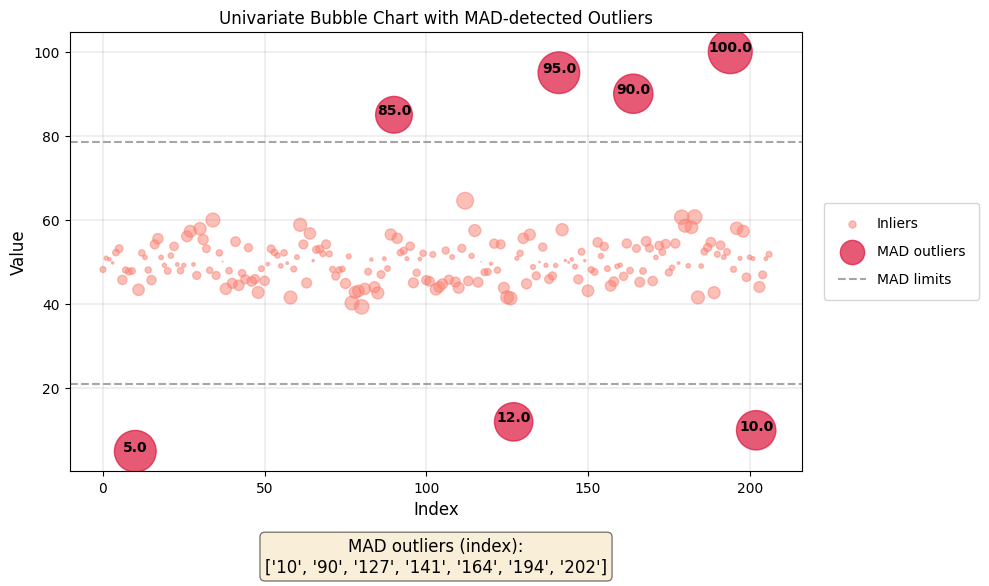

In [8]:
# Reset the sns settings
# from confusion matrix
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Bubble chart of df_univariate with MAD-detected outliers labelled
xseries = df_univariate["index"]
yseries = df_univariate["value"]

# Bubble size scales with the deviation from the mean value
bubble_size = np.abs(yseries - yseries.mean())

# Flag which points were detected as outliers by the MAD method
is_mad_outlier = df_univariate["index"].isin(MAD_outlier_index)

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6))

# Scatterplot for inliers
ax.scatter(
    xseries[~is_mad_outlier],
    yseries[~is_mad_outlier],
    s=bubble_size[~is_mad_outlier] * 10,
    alpha=0.5,
    marker="o",
    c="salmon",
    label="Inliers")

# Scatterplot for MAD-detected outliers
ax.scatter(
    xseries[is_mad_outlier],
    yseries[is_mad_outlier],
    s=bubble_size[is_mad_outlier] * 20,
    alpha=0.7,
    marker="o",
    c="crimson",
    label="MAD outliers")

# Annotate each detected outlier with its value
for idx in MAD_outlier_index:
    ax.text(
        x=xseries[idx],
        y=yseries[idx],
        s=f"{yseries[idx]:.1f}",
        horizontalalignment="center",
        size="medium",
        color="black",
        weight="bold")

# Draw the MAD limits used for detection
ax.axhline(MAD_max_limit, color="grey", linestyle="--", alpha=0.7,
           label="MAD limits")
ax.axhline(MAD_min_limit, color="grey", linestyle="--", alpha=0.7)

# Textbox annotating the detected outlier indices
props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
textstr = "\n".join((
    r"MAD outliers (index):",
    f"{[str(idx) for idx in MAD_outlier_index]}"))
ax.text(
    0.5, -0.15,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    ha="center", va="top",
    bbox=props)

ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Univariate Bubble Chart with MAD-detected Outliers")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.0,
    markerscale=0.6,
    borderpad=1.0)
plt.tight_layout()
plt.show()

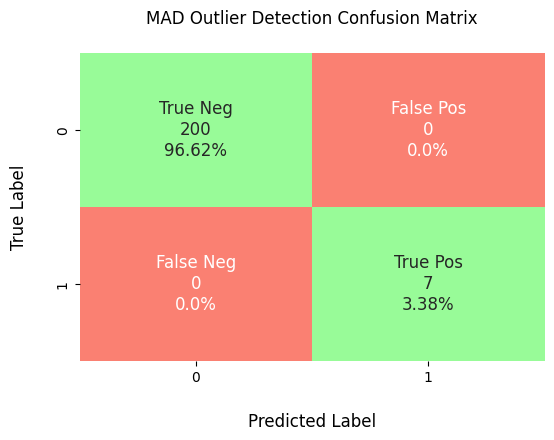

In [9]:
# Compare IQR predicted outliers with the true injected outliers
y_true = df_univariate["value"].isin(outliers)
y_pred = df_univariate["index"].isin(MAD_outlier_index)

# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

fig_title = "MAD Outlier Detection Confusion Matrix"

axplot.set_title(
    fig_title 
    + "\n",
    fontsize=12)

plt.show()

# IQR method

$$
\begin{equation}
IQR = Q_3 - Q_1.
\end{equation}
$$

* The first quartile ($Q_1$) is the median of the lower half of the dataset ($25^\textrm{th}$ percentile)
* The third quartile ($Q_3$) is the median of the upper half of the dataset ($75^\textrm{th}$ percentile).
* IQR is usually visualized using boxplot, where the data distribution can be described based on a five number summary (minimum, Q1, median, Q3 and maximum).
* Measurements are denoted as outliers if they fall outside the lower and upper bound:

$$
\begin{align}
IQR_\textrm{lower} &= Q_1 - (1.5 \times IQR), \nonumber \\
IQR_\textrm{upper} &= Q_3 + (1.5 \times IQR),
\end{align}
$$

In [10]:
# Access the dict of parameters for using 
# the standard deviation method 
iqr_param_dict = bstats.outlier_method["iqr"].params
print(iqr_param_dict)

# Predict the anomalous cycle using interquartile range (IQR) method 
# and the corresponding stats parameters
(IQR_outlier_index,
 IQR_min_limit,
 IQR_max_limit) = bstats.outlier_method["iqr"].compute(
    df_univariate["value"], 
    **iqr_param_dict)

print("*"*70)
print(df_univariate[df_univariate["index"].isin(IQR_outlier_index)])
print("*"*70)

{'iqr_threshold': 1.5}
IQR lower limit: 37.1952706205237
IQR upper limit: 62.49164464342488
**********************************************************************
     index       value
10      10    5.000000
90      90   85.000000
112    112   64.569312
127    127   12.000000
141    141   95.000000
164    164   90.000000
194    194  100.000000
202    202   10.000000
**********************************************************************


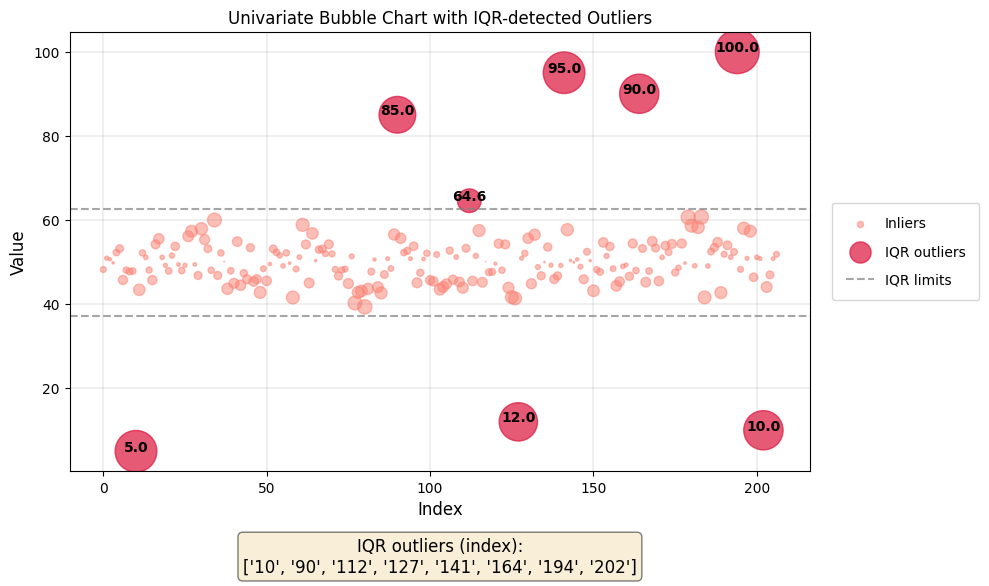

In [11]:
# Reset the sns settings
# from confusion matrix
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Bubble chart of df_univariate with IQR-detected outliers labelled
xseries = df_univariate["index"]
yseries = df_univariate["value"]

# Bubble size scales with the deviation from the mean value
bubble_size = np.abs(yseries - yseries.mean())

# Flag which points were detected as outliers by the IQR method
is_iqr_outlier = df_univariate["index"].isin(IQR_outlier_index)

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6))

# Scatterplot for inliers
ax.scatter(
    xseries[~is_iqr_outlier],
    yseries[~is_iqr_outlier],
    s=bubble_size[~is_iqr_outlier] * 10,
    alpha=0.5,
    marker="o",
    c="salmon",
    label="Inliers")

# Scatterplot for IQR-detected outliers
ax.scatter(
    xseries[is_iqr_outlier],
    yseries[is_iqr_outlier],
    s=bubble_size[is_iqr_outlier] * 20,
    alpha=0.7,
    marker="o",
    c="crimson",
    label="IQR outliers")

# Annotate each detected outlier with its value
for idx in IQR_outlier_index:
    ax.text(
        x=xseries[idx],
        y=yseries[idx],
        s=f"{yseries[idx]:.1f}",
        horizontalalignment="center",
        size="medium",
        color="black",
        weight="bold")

# Draw the IQR limits used for detection
ax.axhline(IQR_max_limit, color="grey", linestyle="--", alpha=0.7,
           label="IQR limits")
ax.axhline(IQR_min_limit, color="grey", linestyle="--", alpha=0.7)

# Textbox annotating the detected outlier indices
props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
textstr = "\n".join((
    r"IQR outliers (index):",
    f"{[str(idx) for idx in IQR_outlier_index]}"))
ax.text(
    0.5, -0.15,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    ha="center", va="top",
    bbox=props)

ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Univariate Bubble Chart with IQR-detected Outliers")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.0,
    markerscale=0.6,
    borderpad=1.0)
plt.tight_layout()
plt.show()

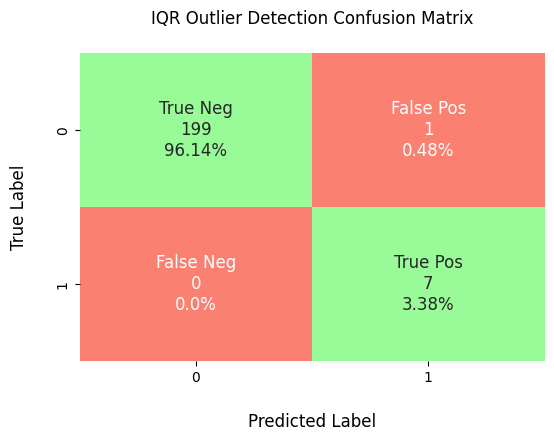

In [12]:
# Compare IQR predicted outliers with the true injected outliers
y_true = df_univariate["value"].isin(outliers)
y_pred = df_univariate["index"].isin(IQR_outlier_index)

# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

fig_title = "IQR Outlier Detection Confusion Matrix"

axplot.set_title(
    fig_title 
    + "\n",
    fontsize=12)

plt.show()

# Z-Score Outlier Detection

$$
\begin{equation}
z_i = \frac{x_i - \mu}{\sigma}
\end{equation}
$$

* $x_i$ denotes the value of each data point in the feature,
* $\mu$ and $\sigma$ are the mean and Z-score of the relevant feature distribution. 

In [13]:
z_transformed_values = bstats.calculate_zscore(df_univariate["value"])

# Access the dict of parameters for using 
# the standard deviation method 
zscore_param_dict = bstats.outlier_method["zscore"].params
print(zscore_param_dict)

# Predict the anomalous cycle using z-score method 
# and the corresponding stats parameters
(Z_outlier_index,
 Z_min_limit,
 Z_max_limit) = bstats.outlier_method["zscore"].compute(
    z_transformed_values,
    **zscore_param_dict)

print("*"*70)
print(df_univariate[df_univariate["index"].isin(Z_outlier_index)])
print("*"*70)

Feature mean: 50.07994819008502
Feature std: 8.893080255727432
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: 2.2311728417587687e-16
Zscore feature std: 0.9999999999999999
{'zscore_threshold': 3.0, 'ddof': 1}
Feature mean: 2.2311728417587687e-16
Feature std: 0.9999999999999999
----------------------------------------------------------------------
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: 8.581434006764495e-18
Zscore feature std: 1.0
Zscore anomalous cycle index: (array([ 10,  90, 127, 141, 164, 194, 202]),)
**********************************************************************
     index  value
10      10    5.0
90      90   85.0
127    127   12.0
141    141   95.0
164    164   90.0
194    194  100.0
202    202   10.0
**********************************************************************


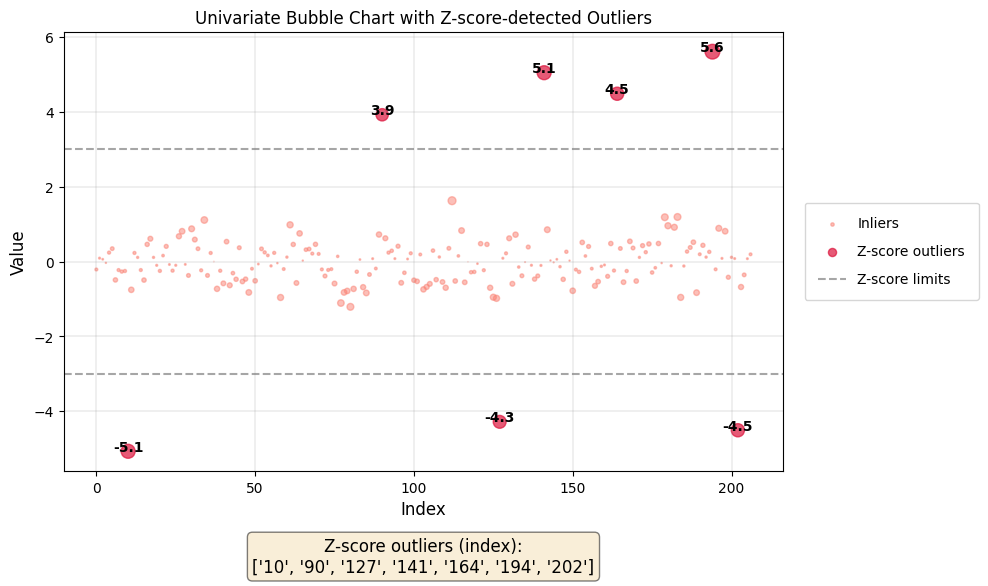

In [14]:
# Reset the sns settings
# from confusion matrix
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Bubble chart of df_univariate with Z-score-detected outliers labelled
xseries = z_transformed_values.index
yseries = z_transformed_values

# Bubble size scales with the deviation from the mean value
bubble_size = np.abs(yseries - yseries.mean())

# Flag which points were detected as outliers by the Z-score method
is_zscore_outlier = z_transformed_values.index.isin(Z_outlier_index)

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6))

# Scatterplot for inliers
ax.scatter(
    xseries[~is_zscore_outlier],
    yseries[~is_zscore_outlier],
    s=bubble_size[~is_zscore_outlier] * 20,
    alpha=0.5,
    marker="o",
    c="salmon",
    label="Inliers")

# Scatterplot for Z-score-detected outliers
ax.scatter(
    xseries[is_zscore_outlier],
    yseries[is_zscore_outlier],
    s=bubble_size[is_zscore_outlier] * 20,
    alpha=0.7,
    marker="o",
    c="crimson",
    label="Z-score outliers")

# Annotate each detected outlier with its value
for idx in Z_outlier_index:
    ax.text(
        x=xseries[idx],
        y=yseries[idx],
        s=f"{yseries[idx]:.1f}",
        horizontalalignment="center",
        size="medium",
        color="black",
        weight="bold")

# Draw the Z-score limits used for detection
ax.axhline(Z_max_limit, color="grey", linestyle="--", alpha=0.7,
           label="Z-score limits")
ax.axhline(Z_min_limit, color="grey", linestyle="--", alpha=0.7)

# Textbox annotating the detected outlier indices
props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
textstr = "\n".join((
    r"Z-score outliers (index):",
    f"{[str(idx) for idx in Z_outlier_index]}"))
ax.text(
    0.5, -0.15,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    ha="center", va="top",
    bbox=props)

ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Univariate Bubble Chart with Z-score-detected Outliers")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.0,
    markerscale=0.6,
    borderpad=1.0)
plt.tight_layout()
plt.show()

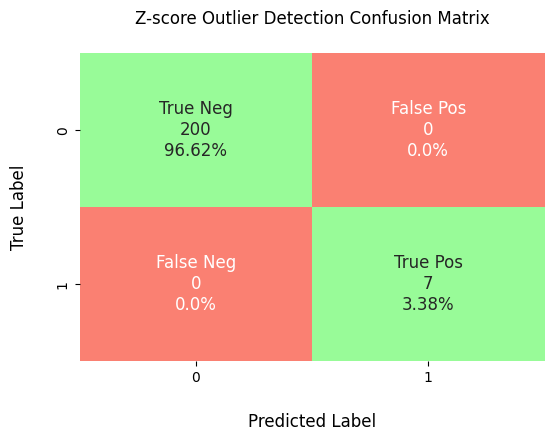

In [15]:
# Compare IQR predicted outliers with the true injected outliers
y_true = df_univariate["value"].isin(outliers)
y_pred = df_univariate["index"].isin(Z_outlier_index)

# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

fig_title = "Z-score Outlier Detection Confusion Matrix"

axplot.set_title(
    fig_title 
    + "\n",
    fontsize=12)

plt.show()

# Modified Z-score

$$
\begin{equation}
\textrm{Modified Z-score} = \frac{x_i - \textrm{median}(X)}{\textrm{MAD}},
\end{equation}
$$

* A coefficient of 0.6745 is sometimes added to the numerator of Equation to make the modified z-score equivalent to the standard Z-score in a Gaussian distribution.
* This coefficient is actually the reciprocal of the MAD-factor ($F_\textrm{MAD} = 1.4826$).
* If the distribution is not Gaussian, then this coefficient should be calculated from the 75th-percentile of the corresponding standard distribution.

In [16]:
z_transformed_values = bstats.calculate_zscore(df_univariate["value"])

# Access the dict of parameters for using 
# the standard deviation method 
mod_zscore_param_dict = bstats.outlier_method["mod_zscore"].params
print(mod_zscore_param_dict)

# Predict the anomalous cycle using z-score method 
# and the corresponding stats parameters
(mod_Z_outlier_index,
 mod_Z_min_limit,
 mod_Z_max_limit) = bstats.outlier_method["mod_zscore"].compute(
    z_transformed_values,
    **mod_zscore_param_dict)

print("*"*70)
print(df_univariate[df_univariate["index"].isin(mod_Z_outlier_index)])
print("*"*70)

Feature mean: 50.07994819008502
Feature std: 8.893080255727432
After Z-transformation, feature mean should be close to 0 and feature std should be close to 1.
Zscore feature mean: 2.2311728417587687e-16
Zscore feature std: 0.9999999999999999
{'mad_factor': None, 'mod_zscore_threshold': 3.5, 'ddof': 1}
Feature median: -0.03706002144802737
Feature z-score mean: 0.0
Feature z-score std. deviation: 1.0
MAD: 1.0784336232365492
Modified Zmin limit: -3.5
Modified Zmax limit: 3.5
**********************************************************************
     index  value
10      10    5.0
90      90   85.0
127    127   12.0
141    141   95.0
164    164   90.0
194    194  100.0
202    202   10.0
**********************************************************************


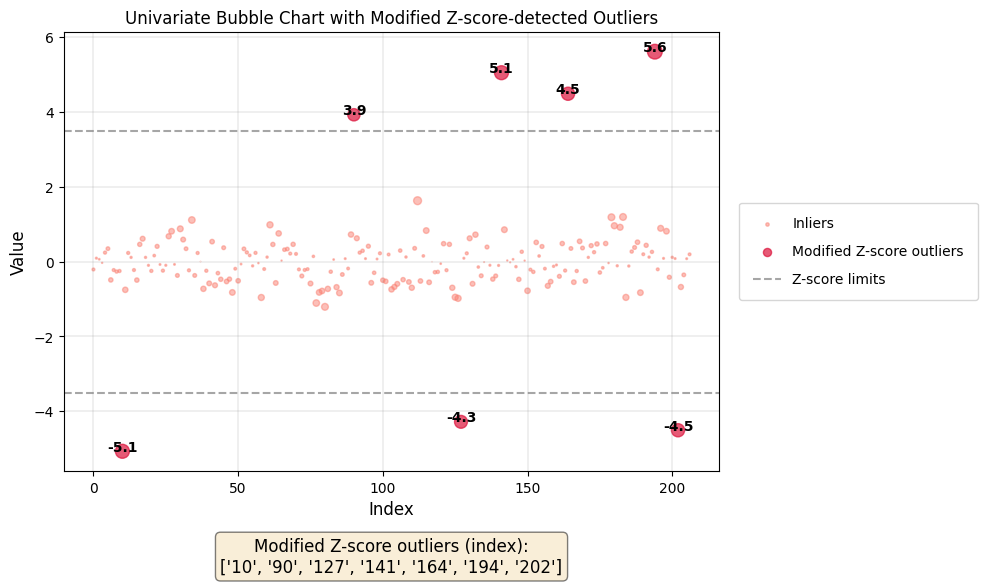

In [17]:
# Reset the sns settings
# from confusion matrix
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Bubble chart of df_univariate with Modified Z-score-detected 
# outliers labelled
xseries = z_transformed_values.index
yseries = z_transformed_values

# Bubble size scales with the deviation from the mean value
bubble_size = np.abs(yseries - yseries.mean())

# Flag which points were detected as outliers by the Modified Z-score method
is_mod_zscore_outlier = z_transformed_values.index.isin(mod_Z_outlier_index)

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6))

# Scatterplot for inliers
ax.scatter(
    xseries[~is_mod_zscore_outlier],
    yseries[~is_mod_zscore_outlier],
    s=bubble_size[~is_mod_zscore_outlier] * 20,
    alpha=0.5,
    marker="o",
    c="salmon",
    label="Inliers")

# Scatterplot for Modified Z-score-detected outliers
ax.scatter(
    xseries[is_mod_zscore_outlier],
    yseries[is_mod_zscore_outlier],
    s=bubble_size[is_mod_zscore_outlier] * 20,
    alpha=0.7,
    marker="o",
    c="crimson",
    label="Modified Z-score outliers")

# Annotate each detected outlier with its value
for idx in mod_Z_outlier_index:
    ax.text(
        x=xseries[idx],
        y=yseries[idx],
        s=f"{yseries[idx]:.1f}",
        horizontalalignment="center",
        size="medium",
        color="black",
        weight="bold")

# Draw the Z-score limits used for detection
ax.axhline(mod_Z_max_limit, color="grey", linestyle="--", alpha=0.7,
           label="Z-score limits")
ax.axhline(mod_Z_min_limit, color="grey", linestyle="--", alpha=0.7)

# Textbox annotating the detected outlier indices
props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
textstr = "\n".join((
    r"Modified Z-score outliers (index):",
    f"{[str(idx) for idx in mod_Z_outlier_index]}"))
ax.text(
    0.5, -0.15,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    ha="center", va="top",
    bbox=props)

ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Univariate Bubble Chart with Modified Z-score-detected Outliers")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    labelspacing=1.0,
    markerscale=0.6,
    borderpad=1.0)
plt.tight_layout()
plt.show()

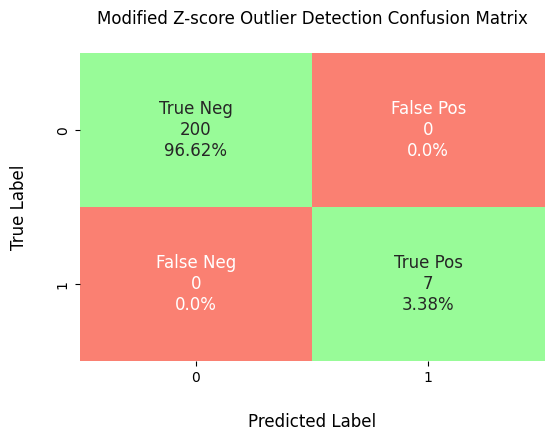

In [18]:
# Compare IQR predicted outliers with the true injected outliers
y_true = df_univariate["value"].isin(outliers)
y_pred = df_univariate["index"].isin(mod_Z_outlier_index)

# Generate custom confusion matrix
axplot = modval.generate_confusion_matrix(
    y_true=np.array(y_true),
    y_pred=np.array(y_pred))

axplot.set_xlabel("Predicted Label", fontsize=12)
axplot.set_ylabel("True Label", fontsize=12)

fig_title = "Modified Z-score Outlier Detection Confusion Matrix"

axplot.set_title(
    fig_title 
    + "\n",
    fontsize=12)

plt.show()